In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import json
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from catboost import CatBoostRegressor

e:\Softwares\anaconda3\envs\RAG\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('medicine_comparison_dataset_netmeds_pharmeasy_apollo.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [3]:
df['month'] = df['timestamp'].dt.month
df['day'] = df['timestamp'].dt.day
df['is_weekend'] = (df['timestamp'].dt.dayofweek >= 5).astype(int)

In [4]:
# Availability score
availability_map = {
    'Available':1,
    'Not Available':0
}

df['availability_score'] = df['availability'].map(availability_map)

# Stock score
stock_map = {
    'In Stock':1,
    'Out of Stock':0
}

df['stock_score'] = df['stock_status'].map(stock_map)

# Prescription flag
prescription_map = {
    'Yes':1,
    'No':0
}

df['prescription_flag'] = df['prescription_required'].map(prescription_map)

# Effective discount
df['effective_discount'] = (
    df['discount_percentage'] +
    df['coupon_discount']
)

# Total savings
df['total_savings'] = (
    df['mrp'] -
    df['final_price']
)

target = 'final_price'

features = [
    'platform',
    'medicine_name',
    'manufacturer',
    'composition',
    'pack_size',
    'mrp',
    'selling_price',
    'discount_percentage',
    'coupon_discount',
    'cashback',
    'availability',
    'delivery_time_hours',
    'prescription_required',
    'platform_rating',
    'review_count',
    'stock_status',
    'day_of_week',
    'festival_indicator',
    'month',
    'day',
    'is_weekend',
    'availability_score',
    'stock_score',
    'prescription_flag',
    'effective_discount',
    'total_savings'
]

X = df[features].copy()
y = df[target]

In [5]:
categorical_features = [
    'platform',
    'medicine_name',
    'manufacturer',
    'composition',
    'pack_size',
    'availability',
    'prescription_required',
    'stock_status',
    'day_of_week'
]

label_encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

In [6]:
numerical_features = [
    col for col in features
    if col not in categorical_features
]

scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])

correlations = X[numerical_features].corrwith(y).abs()
attention_weights = correlations / correlations.sum()

print('='*50)
print('ATTENTION FEATURE WEIGHTS')
print('='*50)
print(attention_weights.sort_values(ascending=False))
print('='*50)

for col in numerical_features:
    X[col] = X[col] * attention_weights[col]

ATTENTION FEATURE WEIGHTS
selling_price          0.255716
mrp                    0.253342
total_savings          0.195248
cashback               0.066456
coupon_discount        0.061661
review_count           0.043572
prescription_flag      0.036408
effective_discount     0.035322
discount_percentage    0.024906
delivery_time_hours    0.007963
festival_indicator     0.006241
platform_rating        0.004299
month                  0.002921
stock_score            0.002555
is_weekend             0.002486
day                    0.000905
availability_score          NaN
dtype: float64


e:\Softwares\anaconda3\envs\RAG\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
e:\Softwares\anaconda3\envs\RAG\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
model = CatBoostRegressor(
    iterations=700,
    learning_rate=0.03,
    depth=8,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    eval_set=(X_test, y_test),
    use_best_model=True
)


0:	learn: 82.5050253	test: 81.5580036	best: 81.5580036 (0)	total: 162ms	remaining: 1m 53s
100:	learn: 7.1589036	test: 7.2887219	best: 7.2887219 (100)	total: 781ms	remaining: 4.63s
200:	learn: 2.6492843	test: 3.3112648	best: 3.3112648 (200)	total: 1.41s	remaining: 3.5s
300:	learn: 2.0025099	test: 2.8058727	best: 2.8058727 (300)	total: 2.03s	remaining: 2.69s
400:	learn: 1.6646984	test: 2.5664134	best: 2.5664134 (400)	total: 2.62s	remaining: 1.96s
500:	learn: 1.4501703	test: 2.4298361	best: 2.4298361 (500)	total: 3.28s	remaining: 1.3s
600:	learn: 1.2741548	test: 2.3280723	best: 2.3280723 (600)	total: 3.92s	remaining: 646ms
699:	learn: 1.1466807	test: 2.2622465	best: 2.2622465 (699)	total: 4.57s	remaining: 0us

bestTest = 2.262246544
bestIteration = 699



CatBoostRegressor(depth=8, eval_metric='RMSE', iterations=700, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=100)

In [9]:
y_pred = model.predict(X_test)

In [10]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
r2 = r2_score(y_test, y_pred)

print('='*60)
print('MEDICINE AEECF PERFORMANCE')
print('='*60)
print(f'MAE   : {mae:.4f}')
print(f'RMSE  : {rmse:.4f}')
print(f'MAPE  : {mape:.4f}%')
print(f'R²    : {r2:.4f}')
print('='*60)

MEDICINE AEECF PERFORMANCE
MAE   : 1.1568
RMSE  : 2.2622
MAPE  : 1.3496%
R²    : 0.9993


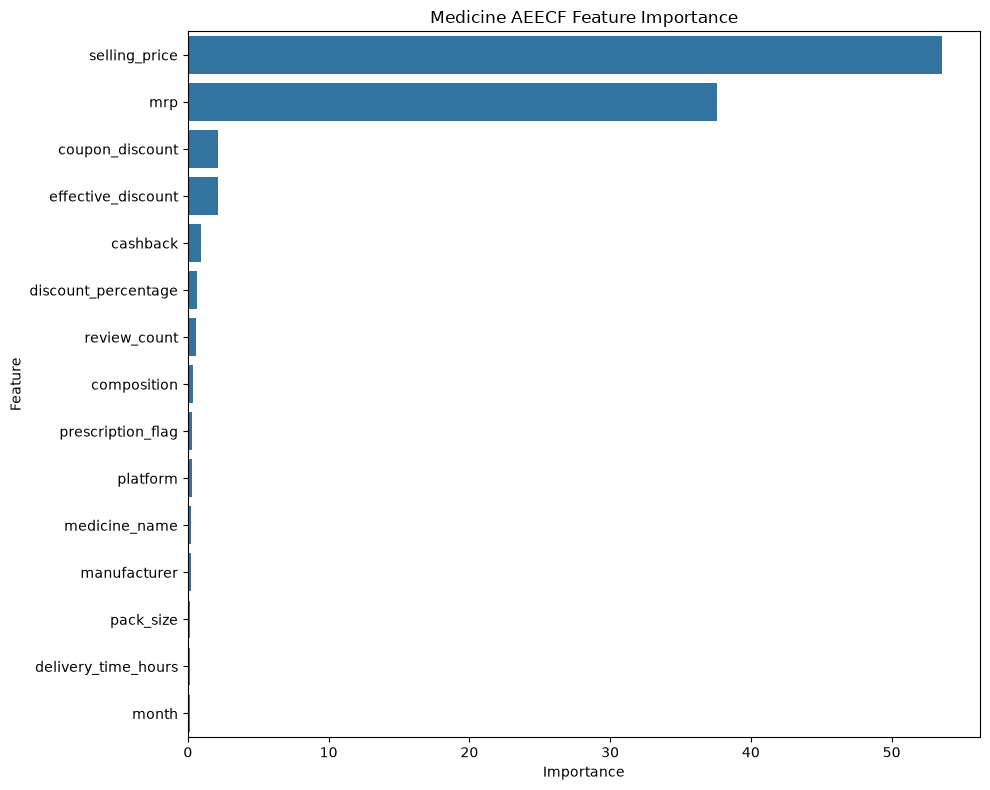

In [11]:
importance = model.get_feature_importance()

importance_df = pd.DataFrame({
    'Feature':features,
    'Importance':importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(
    data=importance_df.head(15),
    x='Importance',
    y='Feature'
)
plt.title('Medicine AEECF Feature Importance')
plt.tight_layout()
plt.savefig('medicine_feature_importance.png')
plt.show()

In [12]:
explainer = shap.TreeExplainer(model)

sample = X_test.sample(200, random_state=42)

shap_values = explainer.shap_values(sample)

shap.summary_plot(
    shap_values,
    sample,
    show=False
)

plt.tight_layout()
plt.savefig('medicine_shap_summary.png')
plt.close()

In [13]:
residuals = y_test - y_pred
residual_std = residuals.std()

lower_bound = y_pred - 1.96 * residual_std
upper_bound = y_pred + 1.96 * residual_std

confidence = []

for l,u in zip(lower_bound, upper_bound):
    width = u - l
    conf = max(0, 1 - width / max(y))
    confidence.append(conf)

confidence = np.mean(confidence)

print(f'Average Prediction Confidence: {confidence:.4f}')

Average Prediction Confidence: 0.9832


In [14]:
os.makedirs('medicine_model', exist_ok=True)

joblib.dump(model, 'medicine_model/aeecf_medicine_catboost_model.pkl')
joblib.dump(scaler, 'medicine_model/scaler.pkl')
joblib.dump(label_encoders, 'medicine_model/label_encoders.pkl')
joblib.dump(attention_weights, 'medicine_model/attention_weights.pkl')
joblib.dump(features, 'medicine_model/feature_columns.pkl')

metrics = {
    'MAE':float(mae),
    'RMSE':float(rmse),
    'MAPE':float(mape),
    'R2':float(r2),
    'Confidence':float(confidence)
}

with open('medicine_model/model_metrics.json','w') as f:
    json.dump(metrics,f,indent=4)

importance_df.to_csv(
    'medicine_model/feature_importance.csv',
    index=False
)

print('Medicine AEECF model saved successfully!')

Medicine AEECF model saved successfully!


In [15]:
def predict_medicine_price(input_dataframe):
    prediction = model.predict(input_dataframe)
    return prediction

print('Medicine model ready for Django integration!')

Medicine model ready for Django integration!
